In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Airline_Delay_Cause.csv")

df.head()

,year,month,carrier,carrier_name,airport,airport_name,arr_flights,arr_del15,carrier_ct,weather_ct,...,security_ct,late_aircraft_ct,arr_cancelled,arr_diverted,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
0,2025,1,G4,Allegiant Air,ELM,"Elmira/Corning, NY: Elmira/Corning Regional",30.0,0.0,0.00,0.0,...,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2025,1,G4,Allegiant Air,ELP,"El Paso, TX: El Paso International",2.0,0.0,0.00,0.0,...,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2025,1,G4,Allegiant Air,EUG,"Eugene, OR: Mahlon Sweet Field",28.0,8.0,3.74,0.0,...,0.0,2.66,2.0,0.0,409.0,236.0,0.0,70.0,0.0,103.0
3,2025,1,G4,Allegiant Air,EVV,"Evansville, IN: Evansville Regional",18.0,1.0,0.00,1.0,...,0.0,0.00,0.0,0.0,1075.0,0.0,1075.0,0.0,0.0,0.0
4,2025,1,G4,Allegiant Air,EWR,"Newark, NJ: Newark Liberty International",31.0,5.0,2.17,0.0,...,0.0,0.00,1.0,0.0,446.0,336.0,0.0,110.0,0.0,0.0


In [2]:
# Cleaning Dataset

df = df.drop_duplicates()

text_cols = df.select_dtypes(include="object").columns
for col in text_cols:
    df[col] = df[col].str.strip()

num_cols = df.select_dtypes(include=np.number).columns
df[num_cols] = df[num_cols].mask(df[num_cols] < 0)

df = df.dropna()

df["delay_rate"] = df["arr_del15"] / df["arr_flights"]
df["cancel_rate"] = df["arr_cancelled"] / df["arr_flights"]
df["diversion_rate"] = df["arr_diverted"] / df["arr_flights"]
df["avg_delay_minutes_per_flight"] = df["arr_delay"] / df["arr_flights"]

df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna()

df["high_delay"] = (df["delay_rate"] >= 0.20).astype(int)

print("Cleaned shape:", df.shape)
df.head()

Cleaned shape: (397281, 26)


,year,month,carrier,carrier_name,airport,airport_name,arr_flights,arr_del15,carrier_ct,weather_ct,...,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay,delay_rate,cancel_rate,diversion_rate,avg_delay_minutes_per_flight,high_delay
0,2025,1,G4,Allegiant Air,ELM,"Elmira/Corning, NY: Elmira/Corning Regional",30.0,0.0,0.00,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0
1,2025,1,G4,Allegiant Air,ELP,"El Paso, TX: El Paso International",2.0,0.0,0.00,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0
2,2025,1,G4,Allegiant Air,EUG,"Eugene, OR: Mahlon Sweet Field",28.0,8.0,3.74,0.0,...,236.0,0.0,70.0,0.0,103.0,0.285714,0.071429,0.0,14.607143,1
3,2025,1,G4,Allegiant Air,EVV,"Evansville, IN: Evansville Regional",18.0,1.0,0.00,1.0,...,0.0,1075.0,0.0,0.0,0.0,0.055556,0.000000,0.0,59.722222,0
4,2025,1,G4,Allegiant Air,EWR,"Newark, NJ: Newark Liberty International",31.0,5.0,2.17,0.0,...,336.0,0.0,110.0,0.0,0.0,0.161290,0.032258,0.0,14.387097,0


In [3]:
# Save Cleaned Dataset

df.to_csv("Airline_Delay_Cause_cleaned.csv", index=False)

In [ ]:
# Dataset Highlights

df.columns

print("Shape:", df.shape)

df.info()

df.describe()

In [4]:
# Missing Values After Cleaning

missing = df.isnull().sum()

missing[missing > 0].sort_values(ascending=False)

,0


In [5]:
missing = df.isnull().sum()

if missing.sum() == 0:
    print("No missing values after cleaning.")
else:
    missing[missing > 0].plot(kind="bar", figsize=(8,5))
    plt.title("Missing Values by Column")
    plt.ylabel("Count")
    plt.show()

No missing values after cleaning.


In [6]:
# Delay Rate Insights

df[["arr_flights", "arr_del15", "delay_rate"]].head()

overall_delay_rate = df["arr_del15"].sum() / df["arr_flights"].sum()
print("Overall delay rate:", overall_delay_rate)

Overall delay rate: 0.19228849690301414


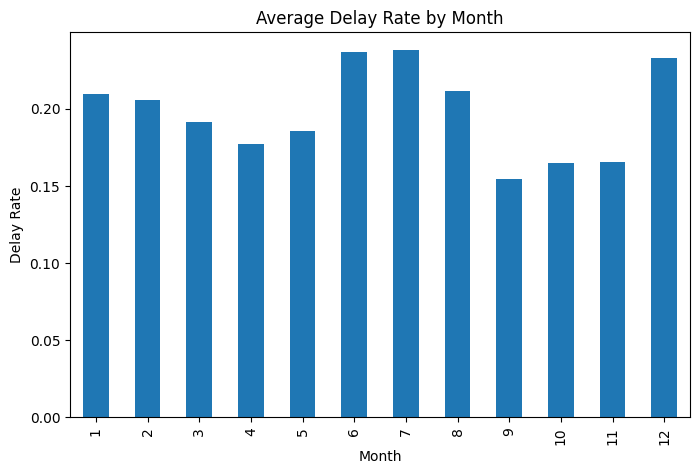

In [7]:
monthly = df.groupby("month")["delay_rate"].mean()

monthly.plot(kind="bar", figsize=(8,5))
plt.title("Average Delay Rate by Month")
plt.xlabel("Month")
plt.ylabel("Delay Rate")
plt.show()

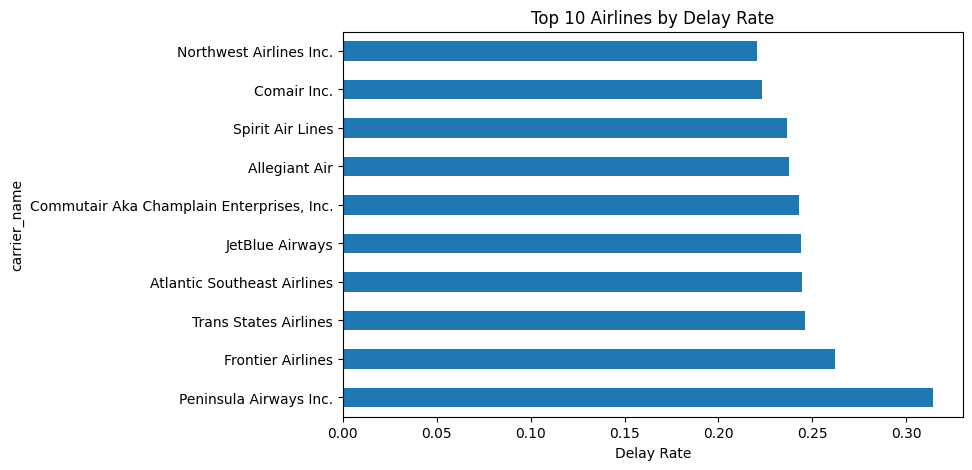

In [9]:
# Delay by Airlines

airline_delay = (
    df.groupby("carrier_name")
    .agg({"arr_flights": "sum", "arr_del15": "sum"})
)

airline_delay["delay_rate"] = airline_delay["arr_del15"] / airline_delay["arr_flights"]

airline_delay.sort_values("delay_rate", ascending=False).head(10)["delay_rate"].plot(
    kind="barh", figsize=(8,5)
)

plt.title("Top 10 Airlines by Delay Rate")
plt.xlabel("Delay Rate")
plt.show()

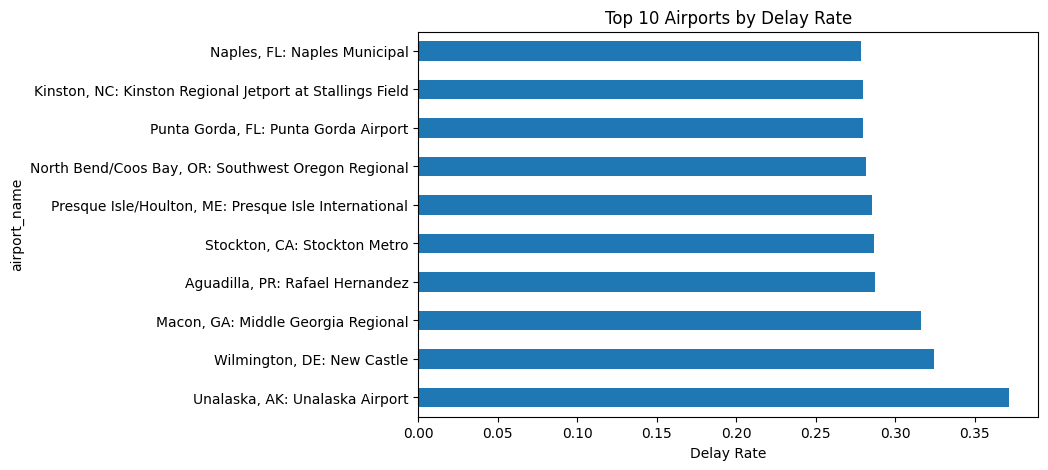

In [10]:
# Delay by Airport

airport_delay = (
    df.groupby("airport_name")
    .agg({"arr_flights": "sum", "arr_del15": "sum"})
)

airport_delay = airport_delay[airport_delay["arr_flights"] > 1000]
airport_delay["delay_rate"] = airport_delay["arr_del15"] / airport_delay["arr_flights"]

airport_delay.sort_values("delay_rate", ascending=False).head(10)["delay_rate"].plot(
    kind="barh", figsize=(8,5)
)

plt.title("Top 10 Airports by Delay Rate")
plt.xlabel("Delay Rate")
plt.show()

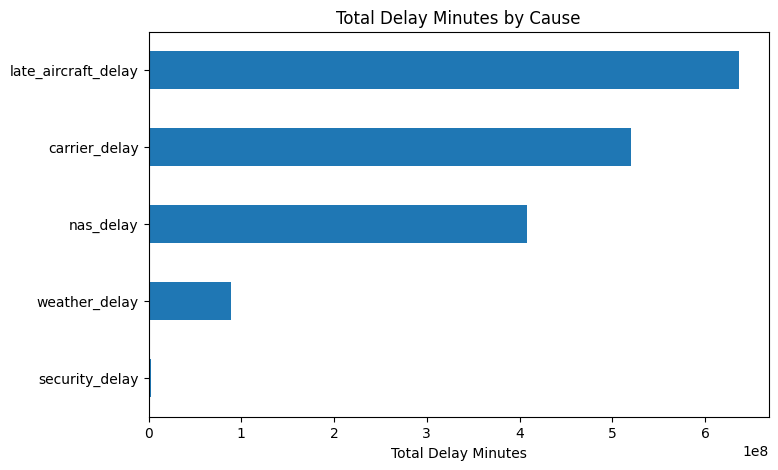

In [11]:
# Delays by Cause

delay_causes = [
    "carrier_delay",
    "weather_delay",
    "nas_delay",
    "security_delay",
    "late_aircraft_delay"
]

df[delay_causes].sum().sort_values().plot(kind="barh", figsize=(8,5))

plt.title("Total Delay Minutes by Cause")
plt.xlabel("Total Delay Minutes")
plt.show()

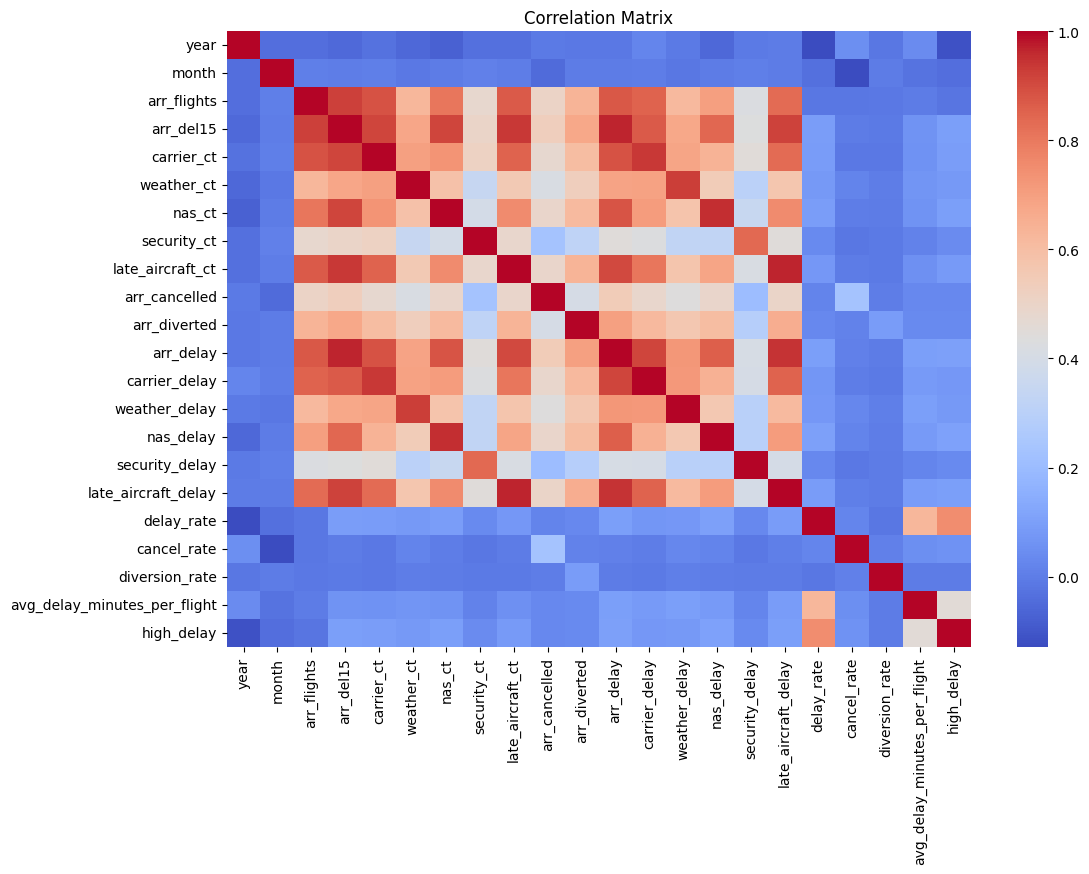

In [12]:
# Factor Correlation

numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(12,8))
sns.heatmap(numeric_df.corr(), cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [13]:
# Target Variable for Modeling

df["high_delay"].value_counts(normalize=True)

,proportion
high_delay,
0,0.554421
1,0.445579


In [14]:
from google.colab import files

files.download("Airline_Delay_Cause_cleaned.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [15]:
# To reduce size of dataset

df_sample = df.sample(n=60000, random_state=42)

df_sample.to_csv("Airline_Delay_Cause_cleaned_sample_60k.csv", index=False)

In [17]:
from google.colab import files
files.download("Airline_Delay_Cause_cleaned_sample_60k.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>